### 1번 문제

1. num_1 폴더의 파일을 데이터프레임으로 불러온다.
2. 데이터프레임의 오류를 확인하고 오류를 수정한다. (item_price의 결측치는 해당 item_name의 item_price의 최대값으로 변경해준다.)
3. 2개의 데이터프레임을 고객의 이름으로 조인 결합한다. 
4. 3번 과정의 결합한 데이터월 '년월' 컬럼을 추가한다. 
5. '년월' 컬럼을 기준으로 pivot_table을 이용하여 'item_name','itme_price'별 'item_price', '고객이름', '지역' 순으로 데이터를 집계한다. 

In [1]:
import pandas as pd
import datetime
import re




In [2]:
# 1. num_1 폴더의 파일을 데이터프레임으로 불러온다.
uriage=pd.read_csv('C:/Users/jangd/OneDrive/사진/문서/GitHub/git_hub_0420/problem/prob_3/num_1/uriage.csv')

kokyaky=pd.read_excel('C:/Users/jangd/OneDrive/사진/문서/GitHub/git_hub_0420/problem/prob_3/num_1/kokyaku_daicho.xlsx',engine='openpyxl')

In [3]:
kokyaky

,고객이름,지역,등록일
0,김 현성,H시,2018-01-04 00:00:00
1,김 도윤,E시,42782
2,김 지한,A시,2018-01-07 00:00:00
3,김 하윤,F시,42872
4,김 시온,E시,43127
...,...,...,...
195,김 재희,G시,2017-06-20 00:00:00
196,김 도영,E시,2018-06-20 00:00:00
197,김 이안,F시,2017-04-29 00:00:00
198,김 시현,H시,2019-04-19 00:00:00


In [4]:
uriage

,purchase_date,item_name,item_price,customer_name
0,2019-06-13 18:02,상품A,100.0,김가온
1,2019-07-13 13:05,상 품 S,NaN,김우찬
2,2019-05-11 19:42,상 품 a,NaN,김유찬
3,2019-02-12 23:40,상품Z,2600.0,김재현
4,2019-04-22 3:09,상품a,NaN,김강현
...,...,...,...,...
2994,2019-02-15 2:56,상품Y,2500.0,김정민
2995,2019-06-22 4:03,상품M,1300.0,김재원
2996,2019-03-29 11:14,상품Q,NaN,김지율
2997,2019-07-14 12:56,상품H,NaN,김승주


In [5]:
kokyaky['고객이름']=kokyaky['고객이름'].str.replace(" ","")
def excel_n2d(num):
	return (datetime.date(1899,12,30) + datetime.timedelta(int(num))).strftime('%Y-%m-%d')
for i in range(200):
   if type(kokyaky['등록일'][i])!=datetime.datetime:
      kokyaky['등록일'][i]=excel_n2d(kokyaky['등록일'][i])
   else:
      kokyaky['등록일'][i]=kokyaky['등록일'][i].strftime('%Y-%m-%d')
      
kokyaky

,고객이름,지역,등록일
0,김현성,H시,2018-01-04
1,김도윤,E시,2017-02-16
2,김지한,A시,2018-01-07
3,김하윤,F시,2017-05-17
4,김시온,E시,2018-01-27
...,...,...,...
195,김재희,G시,2017-06-20
196,김도영,E시,2018-06-20
197,김이안,F시,2017-04-29
198,김시현,H시,2019-04-19


In [6]:
uriage['item_name']=uriage['item_name'].str.replace(" ","")
uriage['item_name']=uriage['item_name'].str.upper()
for i in range(26):
    for j in range(2999):
        if (uriage['item_name'][j] == uriage['item_name'].unique()[i])==True:
            uriage['item_price'][j]=uriage['item_price'].loc[uriage['item_name']==uriage['item_name'].unique()[i]].max()
uriage



c:\Users\jangd\AppData\Local\Programs\Python\Python36\lib\site-packages\ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


,purchase_date,item_name,item_price,customer_name
0,2019-06-13 18:02,상품A,100.0,김가온
1,2019-07-13 13:05,상품S,1900.0,김우찬
2,2019-05-11 19:42,상품A,100.0,김유찬
3,2019-02-12 23:40,상품Z,2600.0,김재현
4,2019-04-22 3:09,상품A,100.0,김강현
...,...,...,...,...
2994,2019-02-15 2:56,상품Y,2500.0,김정민
2995,2019-06-22 4:03,상품M,1300.0,김재원
2996,2019-03-29 11:14,상품Q,1700.0,김지율
2997,2019-07-14 12:56,상품H,800.0,김승주


In [7]:
# 3. 2개의 데이터프레임을 고객의 이름으로 조인 결합한다. 
df=pd.merge(uriage, kokyaky, left_on="customer_name",right_on="고객이름")
df.drop("고객이름",axis=1,inplace=True)
df

,purchase_date,item_name,item_price,customer_name,지역,등록일
0,2019-06-13 18:02,상품A,100.0,김가온,C시,2017-01-26
1,2019-06-14 9:08,상품A,100.0,김가온,C시,2017-01-26
2,2019-01-30 6:49,상품J,1000.0,김가온,C시,2017-01-26
3,2019-07-30 9:17,상품X,2400.0,김가온,C시,2017-01-26
4,2019-04-07 9:37,상품A,100.0,김가온,C시,2017-01-26
...,...,...,...,...,...,...
2994,2019-05-22 19:45,상품Q,1700.0,김현진,H시,2017-07-13
2995,2019-04-14 4:16,상품L,1200.0,김현진,H시,2017-07-13
2996,2019-06-24 2:56,상품A,100.0,김현진,H시,2017-07-13
2997,2019-06-30 18:30,상품X,2400.0,김현진,H시,2017-07-13


In [8]:
df['purchase_date']=pd.to_datetime(df['purchase_date'])
df['등록일']=pd.to_datetime(df['등록일'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2999 entries, 0 to 2998
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   purchase_date  2999 non-null   datetime64[ns]
 1   item_name      2999 non-null   object        
 2   item_price     2999 non-null   float64       
 3   customer_name  2999 non-null   object        
 4   지역             2999 non-null   object        
 5   등록일            2999 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(1), object(3)
memory usage: 164.0+ KB


In [10]:
# 3번 과정의 결합한 데이터월 '년월' 컬럼을 추가한다. 

df['등록년월']=df['등록일'].dt.strftime('%Y%m')
df['purchase_date년월']=df['purchase_date'].dt.strftime('%Y%m')
df

,purchase_date,item_name,item_price,customer_name,지역,등록일,등록년월,purchase_date년월
0,2019-06-13 18:02:00,상품A,100.0,김가온,C시,2017-01-26,201701,201906
1,2019-06-14 09:08:00,상품A,100.0,김가온,C시,2017-01-26,201701,201906
2,2019-01-30 06:49:00,상품J,1000.0,김가온,C시,2017-01-26,201701,201901
3,2019-07-30 09:17:00,상품X,2400.0,김가온,C시,2017-01-26,201701,201907
4,2019-04-07 09:37:00,상품A,100.0,김가온,C시,2017-01-26,201701,201904
...,...,...,...,...,...,...,...,...
2994,2019-05-22 19:45:00,상품Q,1700.0,김현진,H시,2017-07-13,201707,201905
2995,2019-04-14 04:16:00,상품L,1200.0,김현진,H시,2017-07-13,201707,201904
2996,2019-06-24 02:56:00,상품A,100.0,김현진,H시,2017-07-13,201707,201906
2997,2019-06-30 18:30:00,상품X,2400.0,김현진,H시,2017-07-13,201707,201906


In [11]:
#5. '년월' 컬럼을 기준으로 pivot_table을 이용하여 'item_name','itme_price'별 'item_price', '고객이름', '지역' 순으로 데이터를 집계한다. 
pdprice = pd.pivot_table(df,
                     index = ['등록년월'],
                     columns = ['item_name'],
                      aggfunc="size",
                      fill_value=0
                     )
pdprice

item_name,상품A,상품B,상품C,상품D,상품E,상품F,상품G,상품H,상품I,상품J,...,상품Q,상품R,상품S,상품T,상품U,상품V,상품W,상품X,상품Y,상품Z
등록년월,,,,,,,,,,,,,,,,,,,,,
201701,13,8,17,10,6,9,9,12,9,11,...,11,8,3,11,12,11,11,6,10,0
201702,7,6,7,5,4,7,3,12,7,7,...,7,9,9,5,2,9,8,10,10,0
201703,10,3,12,14,8,15,9,7,14,10,...,7,9,7,9,4,11,11,8,4,0
201704,10,9,9,11,4,10,12,9,9,5,...,17,9,17,8,5,4,12,7,9,0
201705,10,6,16,12,3,8,4,7,10,11,...,10,10,7,5,8,13,8,8,5,0
201706,12,5,9,7,7,6,7,4,6,8,...,5,9,8,10,11,8,6,4,3,0
201707,10,9,9,10,13,12,5,8,9,6,...,13,14,14,7,11,8,8,16,12,0
201801,7,4,5,4,14,12,14,7,6,13,...,6,13,7,5,6,8,3,3,5,0
201802,12,15,11,10,11,8,10,3,6,9,...,6,16,7,14,13,8,6,11,9,0


In [12]:
#5. '년월' 컬럼을 기준으로 pivot_table을 이용하여 'item_name','itme_price'별 'item_price', '고객이름', '지역' 순으로 데이터를 집계한다. 
pdprice = pd.pivot_table(df,
                     index = ['등록년월'],
                     columns = ['item_name'],
                     values='item_price',
                    aggfunc="sum",
                      fill_value=0
                     )
pdprice

item_name,상품A,상품B,상품C,상품D,상품E,상품F,상품G,상품H,상품I,상품J,...,상품Q,상품R,상품S,상품T,상품U,상품V,상품W,상품X,상품Y,상품Z
등록년월,,,,,,,,,,,,,,,,,,,,,
201701,1300,1600,5100,4000,3000,5400,6300,9600,8100,11000,...,18700,14400,5700,22000,25200,24200,25300,14400,25000,0
201702,700,1200,2100,2000,2000,4200,2100,9600,6300,7000,...,11900,16200,17100,10000,4200,19800,18400,24000,25000,0
201703,1000,600,3600,5600,4000,9000,6300,5600,12600,10000,...,11900,16200,13300,18000,8400,24200,25300,19200,10000,0
201704,1000,1800,2700,4400,2000,6000,8400,7200,8100,5000,...,28900,16200,32300,16000,10500,8800,27600,16800,22500,0
201705,1000,1200,4800,4800,1500,4800,2800,5600,9000,11000,...,17000,18000,13300,10000,16800,28600,18400,19200,12500,0
201706,1200,1000,2700,2800,3500,3600,4900,3200,5400,8000,...,8500,16200,15200,20000,23100,17600,13800,9600,7500,0
201707,1000,1800,2700,4000,6500,7200,3500,6400,8100,6000,...,22100,25200,26600,14000,23100,17600,18400,38400,30000,0
201801,700,800,1500,1600,7000,7200,9800,5600,5400,13000,...,10200,23400,13300,10000,12600,17600,6900,7200,12500,0
201802,1200,3000,3300,4000,5500,4800,7000,2400,5400,9000,...,10200,28800,13300,28000,27300,17600,13800,26400,22500,0


In [13]:
pdcustomer = pd.pivot_table(df,
                     index = ['등록년월'],
                     columns = ['customer_name'],
                    
                    aggfunc="size",
                      fill_value=0
                     )
pdcustomer

customer_name,김가온,김강민,김강현,김건우,김건희,김경민,김규민,김규현,김다온,김대현,...,김현수,김현승,김현우,김현준,김현진,김호준,정도형,정영훈,정우석,정준기
등록년월,,,,,,,,,,,,,,,,,,,,,
201701,17,0,0,0,0,0,23,0,0,24,...,0,0,0,0,0,0,0,0,0,0
201702,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,17
201703,0,0,0,0,0,0,0,16,0,0,...,0,0,0,0,0,0,0,0,0,0
201704,0,0,0,0,0,0,0,0,0,0,...,17,0,0,0,0,0,17,0,0,0
201705,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,10,0,0,0,0
201706,0,4,19,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
201707,0,0,0,0,0,17,0,0,0,0,...,0,0,0,13,10,0,0,0,0,0
201801,0,0,0,0,16,0,0,0,0,0,...,0,18,0,0,0,0,0,0,0,0
201802,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
pdplace = pd.pivot_table(df,
                     index = ['등록년월'],
                     columns = ['지역'],
                    
                    aggfunc="size",
                      fill_value=0
                     )
pdplace

지역,A시,B시,C시,D시,E시,F시,G시,H시
등록년월,,,,,,,,
201701,14,34,54,0,35,43,20,54
201702,0,35,17,0,52,13,46,0
201703,48,19,27,29,0,84,15,0
201704,46,17,31,41,35,45,16,0
201705,34,23,25,0,37,62,14,14
201706,27,11,31,35,0,14,50,19
201707,17,50,0,36,46,18,29,49
201801,43,28,11,31,50,0,12,20
201802,53,23,56,19,15,0,39,44


### 2번 문제

1. num_2폴더의 'market-price.csv' 파일을 데이터프레임으로 불러온다. 
2. 불러온 데이터프레임의 'day'컬럼의 데이터 값을 datetime으로 변경하고 인덱스로 설정한다. 
3. 데이터프레임을 시각화한다. 
4. (AR=2, 차분=1, MA=2) 파라미터로 ARIMA 모델을 학습한다. 
5. 학습한 모델이 학습 데이터에 대해서 예측한 결과만을 시각화한다. 
6. 예측 결과의 마지막 5일과 실제 5일후의 데이터의 비교하여본다. (실제 5일의 데이터는 num_2폴더의 'market-price-test.csv'에 있다.)
7. 예측 결과의 RMSE를 구한다.
8. prophet을 이용하여 ARIMA모델과 같이 5일후의 데이터를 예측해본다. (

    ```
    prophet = Prophet(seasonality_mode='multiplicative', 
                  yearly_seasonality=True,
                  weekly_seasonality=True, daily_seasonality=True,
                  changepoint_prior_scale=0.5)
    ```
    
    prophet의 기본설정은 다음과 같이 한다. 
)
9. 예측 결과의 RMSE를 구한다. 
10. 예측 결과의 더 나은 결과를 내는 방법을 생각해본다. 

In [15]:
import matplotlib.pyplot as plt

In [16]:
# 1. num_2폴더의 'market-price.csv' 파일을 데이터프레임으로 불러온다. 
market=pd.read_csv('./num_2/market-price.csv')
market.columns=['day','price']

In [17]:
# 2. 불러온 데이터프레임의 'day'컬럼의 데이터 값을 datetime으로 변경하고 인덱스로 설정한다. 
market['day']=pd.to_datetime(market['day'])
market.info()
market.set_index('day',inplace=True)
market

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   day     365 non-null    datetime64[ns]
 1   price   365 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.8 KB


,price
day,
2017-08-27,4354.308333
2017-08-28,4391.673517
2017-08-29,4607.985450
2017-08-30,4594.987850
2017-08-31,4748.255000
...,...
2018-08-22,6575.229167
2018-08-23,6434.881667
2018-08-24,6543.645714


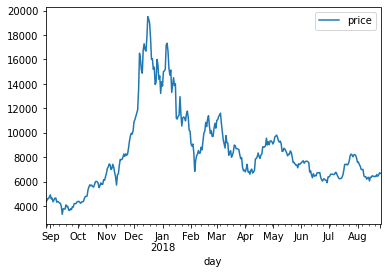

In [18]:
# 3. 데이터프레임을 시각화한다. 
market.plot()
plt.show()

In [19]:
from statsmodels.tsa.arima_model import ARIMA


# (AR=2, 차분=1, MA=2) 파라미터로 ARIMA 모델을 학습합니다.
model = ARIMA(endog=market,order=(2,1,2))

model_fit = model.fit(trend = 'c', full_output = True, disp = 1)
print(model_fit.summary())

c:\Users\jangd\AppData\Local\Programs\Python\Python36\lib\site-packages\statsmodels\tsa\arima_model.py:472: FutureWarning: 
statsmodels.tsa.arima_model.ARMA and statsmodels.tsa.arima_model.ARIMA have
been deprecated in favor of statsmodels.tsa.arima.model.ARIMA (note the .
between arima and model) and
statsmodels.tsa.SARIMAX. These will be removed after the 0.12 release.

statsmodels.tsa.arima.model.ARIMA makes use of the statespace framework and
is both well tested and maintained.

To silence this warning and continue using ARMA and ARIMA until they are
removed, use:

import warnings
warnings.filterwarnings('ignore', 'statsmodels.tsa.arima_model.ARMA',
                        FutureWarning)
warnings.filterwarnings('ignore', 'statsmodels.tsa.arima_model.ARIMA',
                        FutureWarning)

  warnings.warn(ARIMA_DEPRECATION_WARN, FutureWarning)
c:\Users\jangd\AppData\Local\Programs\Python\Python36\lib\site-packages\statsmodels\tsa\base\tsa_model.py:527: ValueWarning: No frequ

                             ARIMA Model Results                              
Dep. Variable:                D.price   No. Observations:                  364
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -2787.553
Method:                       css-mle   S.D. of innovations            512.416
Date:                Sun, 08 May 2022   AIC                           5587.107
Time:                        23:39:29   BIC                           5610.490
Sample:                    08-28-2017   HQIC                          5596.401
                         - 08-26-2018                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             5.8189     27.794      0.209      0.834     -48.657      60.295
ar.L1.D.price    -0.3790      1.830     -0.207      0.836      -3.965       3.207
ar.L2.D.price     0.1584      1.193     

c:\Users\jangd\AppData\Local\Programs\Python\Python36\lib\site-packages\statsmodels\tsa\arima_model.py:472: FutureWarning: 
statsmodels.tsa.arima_model.ARMA and statsmodels.tsa.arima_model.ARIMA have
been deprecated in favor of statsmodels.tsa.arima.model.ARIMA (note the .
between arima and model) and
statsmodels.tsa.SARIMAX. These will be removed after the 0.12 release.

statsmodels.tsa.arima.model.ARIMA makes use of the statespace framework and
is both well tested and maintained.

To silence this warning and continue using ARMA and ARIMA until they are
removed, use:

import warnings
warnings.filterwarnings('ignore', 'statsmodels.tsa.arima_model.ARMA',
                        FutureWarning)
warnings.filterwarnings('ignore', 'statsmodels.tsa.arima_model.ARIMA',
                        FutureWarning)

  warnings.warn(ARIMA_DEPRECATION_WARN, FutureWarning)


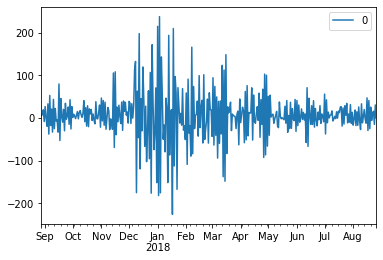

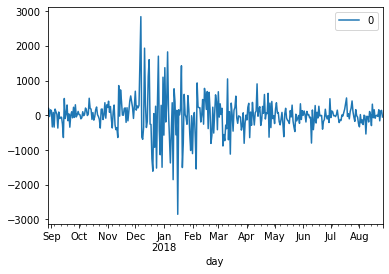

In [20]:
#5. 학습한 모델이 학습 데이터에 대해서 예측한 결과만을 시각화한다. 

fig=model_fit.predict()
fig_df=pd.DataFrame(fig)
residuals = pd.DataFrame(model_fit.resid) 
fig_df.plot()
residuals.plot()
plt.show()


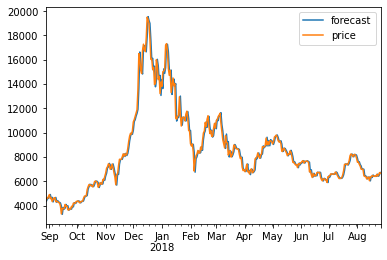

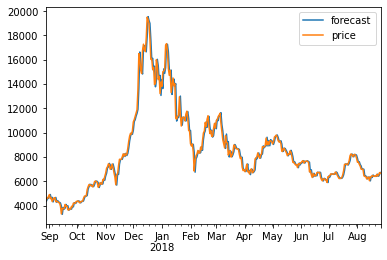

In [21]:
model_fit.plot_predict()

In [22]:
train=pd.read_csv("./num_2/market-price-test.csv")
train
train.columns = ["day", "price"]
train.set_index('day',inplace=True)
train

,price
day,
2018-08-27 0:00,6719.266154
2018-08-28 0:00,7000.040000
2018-08-29 0:00,7054.276429
2018-08-30 0:00,6932.662500
2018-08-31 0:00,6981.946154


In [23]:
forecast_data = model_fit.forecast(steps=5) # 학습 데이터셋으로부터 5일 뒤를 예측합니다.
forecast_data[2]



array([[5672.08525436, 7680.71734531],
       [5207.13378153, 8160.81993267],
       [4895.37708492, 8482.0298225 ],
       [4614.79895415, 8775.63028305],
       [4379.13338984, 9022.06269154]])

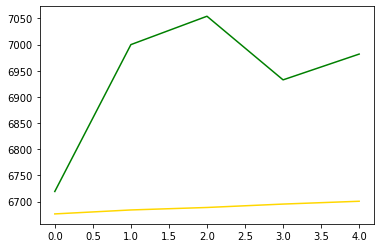

In [24]:
pred_y = list(forecast_data)[0] # 마지막 5일의 예측 데이터입니다. (2018-08-27 ~ 2018-08-31)
test_y = train.price.values # 실제 5일 가격 데이터입니다. (2018-08-27 ~ 2018-08-31)""
plt.plot(pred_y, color="gold") # 모델이 예상한 가격 그래프입니다.
plt.plot(test_y, color="green") # 실제 가격 그래프입니다.

In [26]:
# 7. 예측 결과의 RMSE를 구한다.
import numpy as np
from sklearn.metrics import mean_squared_error 
MSE = mean_squared_error(test_y, pred_y) 
np.sqrt(MSE)

272.36562320837027

In [48]:
from fbprophet import Prophet

In [49]:
# prophet을 사용하기 위해서는 다음과 같이 피처의 이름을 변경해야합니다. :'ds','y'
bitcoin_df=pd.read_csv('C:/Users/jangd/OneDrive/사진/문서/GitHub/git_hub_0420/problem/prob_3/num_2/market-price.csv',names=['ds','y'])
bitcoin_df['ds']=bitcoin_df['ds'].shift(-1)
bitcoin_df['y']=bitcoin_df['y'].shift(-1)
bitcoin_df.drop(index=[365],axis=0,inplace=True)
bitcoin_df
prophet=Prophet(seasonality_mode='multiplicative',
                yearly_seasonality=True,
                weekly_seasonality=True,daily_seasonality=True,
                changepoint_prior_scale=0.5)

prophet.fit(bitcoin_df)
#음영 상한하한값


In [50]:

# 5일을 내다보며 예측합니다.
future_data = prophet.make_future_dataframe(periods=5, freq='d')
forecast_data = prophet.predict(future_data)

In [51]:
forecast_data

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,daily,daily_lower,daily_upper,multiplicative_terms,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,2017-08-27,459.060941,3815.057688,5122.588943,459.060941,459.060941,9.783651,9.783651,9.783651,8.622643,...,-0.042768,-0.042768,-0.042768,-1.118240,-1.118240,-1.118240,0.0,0.0,0.0,4417.379679
1,2017-08-28,461.919547,3862.419351,5148.860052,461.919547,461.919547,9.783651,9.783651,9.783651,8.722503,...,-0.004772,-0.004772,-0.004772,-1.056375,-1.056375,-1.056375,0.0,0.0,0.0,4491.014340
2,2017-08-29,464.778153,3890.028455,5198.635800,464.778153,464.778153,9.783651,9.783651,9.783651,8.792321,...,0.020305,0.020305,0.020305,-1.011635,-1.011635,-1.011635,0.0,0.0,0.0,4551.256882
3,2017-08-30,467.636759,3921.064118,5288.843039,467.636759,467.636759,9.783651,9.783651,9.783651,8.749740,...,-0.046558,-0.046558,-0.046558,-0.987353,-0.987353,-0.987353,0.0,0.0,0.0,4559.336671
4,2017-08-31,470.495365,3956.579678,5218.575996,470.495365,470.495365,9.783651,9.783651,9.783651,8.785631,...,-0.011756,-0.011756,-0.011756,-0.986264,-0.986264,-0.986264,0.0,0.0,0.0,4604.093802
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
365,2018-08-27,722.668048,6326.099775,7632.971529,722.668048,722.668048,9.783651,9.783651,9.783651,8.642938,...,-0.004772,-0.004772,-0.004772,-1.135941,-1.135941,-1.135941,0.0,0.0,0.0,6968.643158
366,2018-08-28,726.623196,6330.699602,7753.442335,726.623196,726.623196,9.783651,9.783651,9.783651,8.733578,...,0.020305,0.020305,0.020305,-1.070378,-1.070378,-1.070378,0.0,0.0,0.0,7072.643283
367,2018-08-29,730.578344,6445.298961,7810.389475,730.294009,730.578344,9.783651,9.783651,9.783651,8.716070,...,-0.046558,-0.046558,-0.046558,-1.021023,-1.021023,-1.021023,0.0,0.0,0.0,7098.350101
368,2018-08-30,734.533491,6434.367035,7950.688256,725.513582,743.167770,9.783651,9.783651,9.783651,8.780550,...,-0.011756,-0.011756,-0.011756,-0.991345,-0.991345,-0.991345,0.0,0.0,0.0,7184.141270


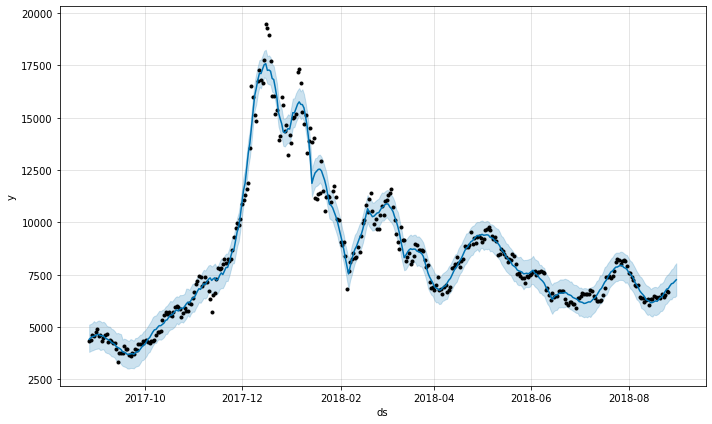

In [52]:
fig1 = prophet.plot(forecast_data)

c:\Users\jangd\AppData\Local\Programs\Python\Python36\lib\site-packages\fbprophet\plot.py:422: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(yticklabels)
c:\Users\jangd\AppData\Local\Programs\Python\Python36\lib\site-packages\fbprophet\plot.py:422: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(yticklabels)
c:\Users\jangd\AppData\Local\Programs\Python\Python36\lib\site-packages\fbprophet\plot.py:422: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(yticklabels)


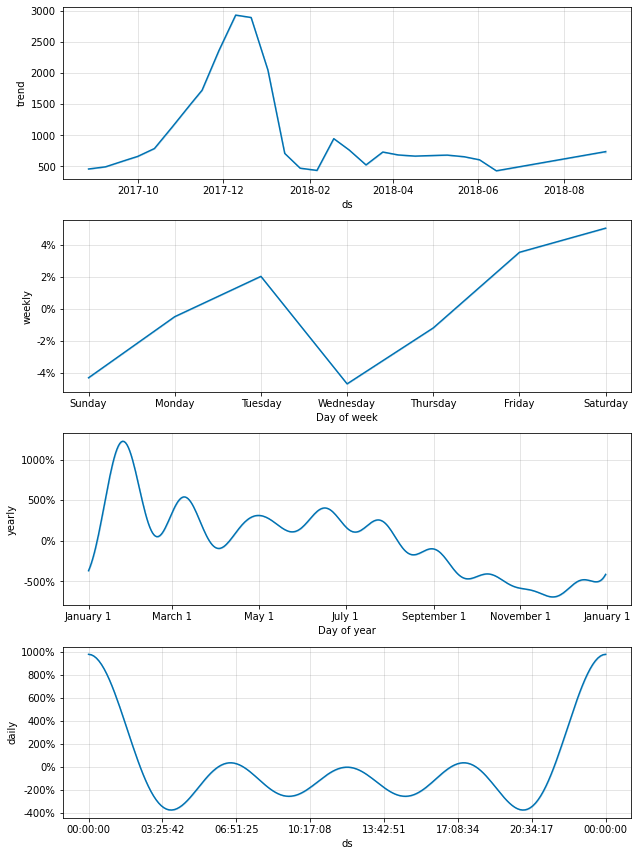

In [53]:
fig2 = prophet.plot_components(forecast_data)

In [54]:
y = bitcoin_df.y.values[5:] # 첫 5일을 제외한 실제 가격 데이터입니다.
y_pred = forecast_data.yhat.values[5:-5] # 첫 5일, 마지막 5일을 제외한 예측 가격 데이터입니다.

In [57]:
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt
rmse = sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)
print(rmse)
print(r2)

523.1858309015173
0.9736886329389345


In [61]:
bitcoin_test_df = pd.read_csv('./num_2/market-price-test.csv', names=['ds', 'y'])

pred_y = forecast_data.yhat.values[-5:] # 마지막 5일의 예측 데이터입니다. (2018-08-27 ~ 2018-08-31)
test_y = bitcoin_test_df.y.values # 실제 5일 가격 데이터입니다. (2018-08-27 ~ 2018-08-31)
pred_y_lower = forecast_data.yhat_lower.values[-5:] # 마지막 5일의 예측 데이터의 최소값입니다.
pred_y_upper = forecast_data.yhat_upper.values[-5:] # 마지막 5일의 예측 데이터의 최대값입니다.

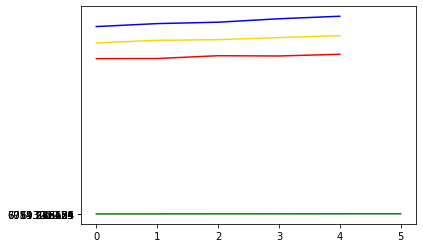

In [62]:
plt.plot(pred_y, color="gold") # 모델이 예상한 가격 그래프입니다.
plt.plot(pred_y_lower, color="red") # 모델이 예상한 최소가격 그래프입니다.
plt.plot(pred_y_upper, color="blue") # 모델이 예상한 최대가격 그래프입니다.
plt.plot(test_y, color="green") # 실제 가격 그래프입니다.}

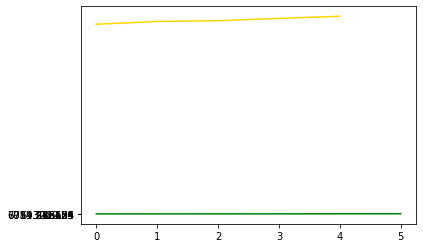

In [63]:
plt.plot(pred_y, color="gold") # 모델이 예상한 가격 그래프입니다.
plt.plot(test_y, color="green") # 실제 가격 그래프입니다.

In [64]:
rmse = sqrt(mean_squared_error(pred_y, test_y))
print(rmse)

ValueError: Found input variables with inconsistent numbers of samples: [5, 6]